# Example 3 — Load Shorkie (8-fold) and predict coverage tracks\nShorkie is the supervised 8-fold ensemble fine-tuned from Shorkie_LM on 5215 ChIP-exo / MNase / RNA-seq\ntracks. It predicts per-bin coverage for all 5215 tracks over a 16,384 bp window (896 bins of 32 bp).\n\n**Prereqs:** `data/download.sh --models finetuned` (8 folds + targets.txt). Model: `models.shorkie_finetuned`.

In [1]:
# Resolve the released model directory via shorkie.config (works on the training
# cluster). External users: run `data/download.sh --models all` and set
# MODEL_OVERRIDE to that local dir, or edit config/paths.yaml:work_root.
import os, json, numpy as np
from shorkie import config
MODEL_OVERRIDE = os.environ.get("SHORKIE_MODELS")  # e.g. ./data_local/models

import pandas as pd, pysam
from shorkie.models.ensemble import load_ensemble, make_input, ensemble_predict

model_dir    = MODEL_OVERRIDE or str(config.path("models.shorkie_finetuned"))   # fold checkpoints
params_file  = "../minimal_example/params.json"   # released params (= models/.../params.json)
targets_file = "../minimal_example/sheet.txt"      # the 5215-track targets sheet (released targets.txt)
fasta = pysam.Fastafile(str(config.path("genome.fasta")))

### Load the 8-fold ensemble (sliced to all 5215 tracks)

In [2]:
targets_df = pd.read_csv(targets_file, index_col=0, sep="\t")
target_index = targets_df.index
print("tracks:", len(target_index))
import io, contextlib
with contextlib.redirect_stdout(io.StringIO()):   # silence 8-fold restore logs
    models = load_ensemble(model_dir, params_file, target_index, num_folds=8)
print('loaded 8-fold Shorkie ensemble')   # f0c0..f7c0

tracks: 5215


2026-06-24 17:24:00.824469: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-24 17:24:00.866971: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-24 17:24:00.866996: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-24 17:24:00.868209: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-24 17:24:00.874874: I tensorflow/core/platform/cpu_feature_guar

2026-06-24 17:24:01.583258: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


loaded 8-fold Shorkie ensemble


### Predict tracks over a window\n`make_input` builds the (16384,170) tensor; `ensemble_predict` averages the 8 folds.

In [3]:
x = make_input(fasta, "chrI", 70000, 70000 + 16384, seq_len=16384)
y = ensemble_predict(models, x)            # (1, 1, 896, 5215) — bins depend on the model's target_length
print("prediction shape:", y.shape)
cov = y[0, 0]                              # (896 bins, 5215 tracks)
print("mean coverage over all tracks at the 10 central bins:", np.round(cov[251:261].mean(1), 3))

prediction shape: (1, 1, 896, 5215)
mean coverage over all tracks at the 10 central bins: [ 4.548  5.189  6.054  7.12   8.184  8.958  9.894 10.623 11.008 11.288]


### Plot one track's predicted coverage across the window

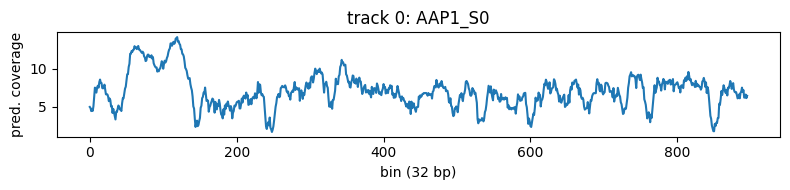

In [4]:
import matplotlib.pyplot as plt
t = 0                                       # track index (see targets_df.iloc[t])
plt.figure(figsize=(8,2)); plt.plot(cov[:, t]); plt.xlabel("bin (32 bp)"); plt.ylabel("pred. coverage")
plt.title(f"track {t}: {targets_df.iloc[t].get('identifier', targets_df.index[t])}"); plt.tight_layout(); plt.show()

Slice `cov[:, track_index]` for any of the 5215 tracks; `src/shorkie/helpers/yeast_helpers.py` has richer coverage-plotting helpers (`plot_coverage_track_bins`).